# 06 — Un modelo por zona (geo-clustering)

**Hipótesis (del EDA, nb 00):** la relación clima–rinde *cambia según la zona*
(fuerte en la Pampa húmeda, casi nula en el norte subtropical). Un único modelo
"pooled" tiene que promediar esas relaciones distintas. Entonces: ¿anda mejor
**un modelo por zona**, cada uno especializado en el clima de su región?

Lo probamos en serio y lo interpretamos zona por zona. Las zonas son las
**geográficas balanceadas** del nb 00 (KMeans sobre lat/lon de los departamentos),
y el modelo es el **XGBoost ganador (nb 03) + features agronómicas (nb 00)**, igual
para el pooled y para cada zona (comparación justa).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
import datos, evaluacion as ev
from modelos import XGBoostRegressor

CULTIVOS = ['soja', 'maiz']; N_ZONAS = 6
_BEST = json.load(open('retuning_cv_honesta.json', encoding='utf-8')) if os.path.exists('retuning_cv_honesta.json') else {}
def best_xgb(c):
    return {k: v for k, v in _BEST.get(c, {}).get('xgb', {}).get('best_params', {}).items() if k != 'n_jobs'}
panel = datos.assign_zonas(datos.load_panel(), n_zonas=N_ZONAS, method='geo')

def analizar_zona(c):
    """Pooled vs. un-modelo-por-zona para un cultivo. Devuelve tabla por zona +
    métricas globales de ambos esquemas."""
    best = best_xgb(c)
    ds_pool = datos.build_reg_dataset(panel, c, use_agro=True, enc_smooth=10.0)
    mp = XGBoostRegressor(**best, random_state=42).fit(ds_pool.X_train, ds_pool.y_train)
    pred = mp.predict(ds_pool.X_test); met_pool = ev.metricas(ds_pool.y_test, pred)
    zt = ds_pool.meta_test['zona'].values
    r2_pool = {z: ev.metricas(ds_pool.y_test[zt == z], pred[zt == z])['r2'] for z in np.unique(zt)}
    zds = datos.build_zona_datasets(c, n_zonas=N_ZONAS, method='geo', use_agro=True, enc_smooth=10.0)
    filas, yt, yp = [], [], []
    for z, dz in zds.items():
        m = XGBoostRegressor(**best, random_state=42).fit(dz.X_train, dz.y_train); pr = m.predict(dz.X_test)
        filas.append({'zona': z, 'n_test': len(dz.y_test), 'R2_pooled': r2_pool.get(z, np.nan),
                      'R2_por_zona': ev.metricas(dz.y_test, pr)['r2']})
        yt.append(dz.y_test); yp.append(pr)
    return dict(pool=met_pool, zona_glob=ev.metricas(np.concatenate(yt), np.concatenate(yp)),
                tabla=pd.DataFrame(filas).sort_values('zona'))

print('zonas:', sorted(panel.zona.dropna().unique()))

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
zonas: ['z0', 'z1', 'z2', 'z3', 'z4', 'z5']


## Pooled vs. un modelo por zona (soja y maíz)

Por zona: R² del pooled dentro de esa zona vs. R² del modelo especializado de la zona.

In [2]:
RES = {c: analizar_zona(c) for c in CULTIVOS}
for c in CULTIVOS:
    print(f'=== {c} ===  pooled global R²={RES[c]["pool"]["r2"]:.3f} | '
          f'un modelo por zona R²={RES[c]["zona_glob"]["r2"]:.3f}')
    display(RES[c]['tabla'])

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
=== soja ===  pooled global R²=0.374 | un modelo por zona R²=0.417


,zona,n_test,R2_pooled,R2_por_zona
0,z0,116,0.222,0.174
1,z1,228,0.567,0.600
2,z2,164,-0.140,0.060
3,z3,237,0.262,0.262
4,z4,72,0.096,0.216
5,z5,125,0.600,0.655


=== maiz ===  pooled global R²=0.265 | un modelo por zona R²=0.369


,zona,n_test,R2_pooled,R2_por_zona
0,z0,209,-0.358,-0.220
1,z1,240,0.380,0.555
2,z2,203,-0.476,-0.422
3,z3,272,0.198,0.290
4,z4,80,-0.078,0.112
5,z5,156,0.481,0.581


### Zona por zona: ¿dónde ayuda especializar?

Barra verde (modelo por zona) contra azul (pooled) en el test de cada zona, por cultivo.

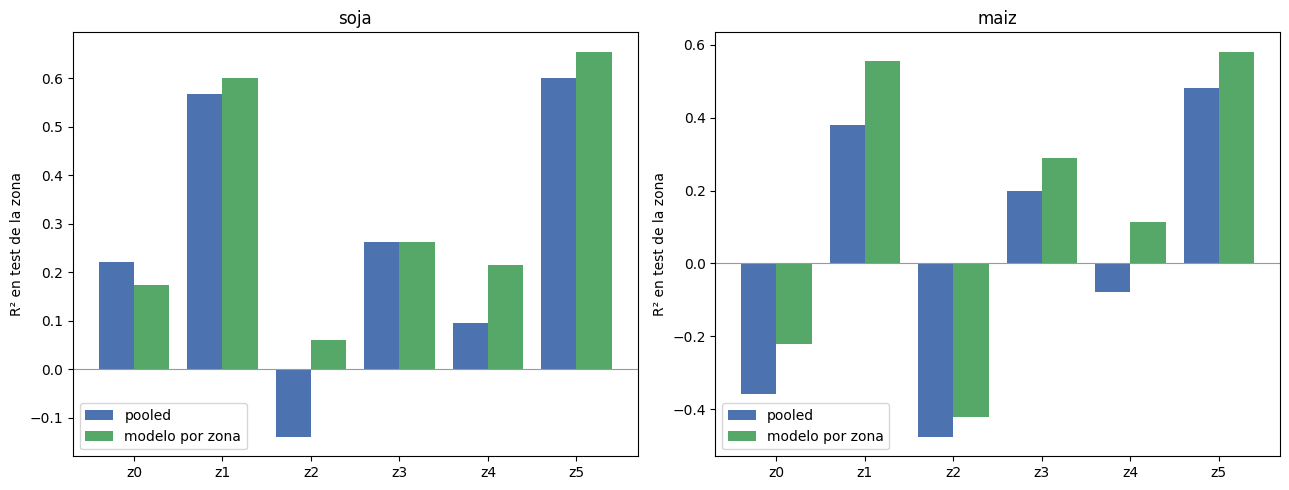

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, c in zip(axes, CULTIVOS):
    t = RES[c]['tabla']; x = np.arange(len(t)); w = 0.4
    ax.bar(x - w/2, t.R2_pooled, w, label='pooled', color='#4C72B0')
    ax.bar(x + w/2, t.R2_por_zona, w, label='modelo por zona', color='#55A868')
    ax.axhline(0, color='0.6', lw=0.8); ax.set_xticks(x); ax.set_xticklabels(t.zona)
    ax.set_ylabel('R² en test de la zona'); ax.set_title(f'{c}'); ax.legend()
plt.tight_layout(); plt.show()

## Interpretación

- **Especializar por zona ayuda donde la señal climática es fuerte y hay datos**
  (las zonas pampeanas: R² sube claramente sobre el pooled) — la hipótesis del EDA
  se cumple *ahí*.
- **Pero rompe en el norte subtropical**: poca señal clima–rinde + menos datos por
  modelo ⇒ sobreajuste y extrapolación catastrófica en test. Esa zona sola hunde la
  métrica global.
- **Neto global: un modelo por zona NO le gana al pooled.** El pooled comparte
  "fuerza estadística" entre zonas (regulariza las zonas ruidosas con las buenas) y
  ya captura lo espacial vía `depto_enc`. Fragmentar los datos pierde eso.

### Cómo hacer que las zonas sí paguen (próximos pasos)
1. **Split selectivo**: modelo por zona solo en las zonas donde mejora (Pampa) y
   pooled para las ruidosas — lo mejor de los dos.
2. **Partial pooling / jerárquico**: un modelo que comparte parámetros entre zonas
   pero deja variar la relación clima–rinde (efectos por zona), sin fragmentar.
3. **Más regularización en zonas chicas/ruidosas** (menos profundidad, más shrinkage)
   o un mínimo de filas más alto por zona.
4. **Cambiar el target a residuo/anomalía** por zona (sacar el nivel espacial), que
   es lo que de verdad depende del clima.

**Conclusión:** el geo-clustering es muy útil como *diagnóstico* (muestra dónde el
clima predice y dónde no), pero "un modelo por zona" a secas no mejora el global;
el camino es el pooling parcial o el split selectivo.